In [2]:
"""
Exploratory data analysis of movie_roi.csv

Questions:
  1. Average budget and revenue by year
  2. Domestic vs foreign breakdown by year and by genre
  3. Do blockbuster (huge-budget) movies follow different trends?

Outputs four PNG charts in the same folder as this script.
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

DATA_PATH = "movie_roi.csv"          # change if your file lives elsewhere
BLOCKBUSTER_BUDGET = 100_000_000     # $100M+ production budget = blockbuster
MIN_GENRE_FILMS = 40                 # skip tiny genres (Western, Documentary, ...)

plt.rcParams.update({
    "figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})
C_BUDGET, C_DOM, C_FOR, C_WW = "#6c757d", "#1f77b4", "#ff7f0e", "#2ca02c"
C_BB, C_OTHER = "#d62728", "#7f7f7f"

millions = mtick.FuncFormatter(lambda x, _: f"${x/1e6:,.0f}M")
billions = mtick.FuncFormatter(lambda x, _: f"${x/1e9:,.0f}B")


# ---------------------------------------------------------------- load / clean
raw = pd.read_csv(DATA_PATH)

# 1) Films with no reported box office have 0 revenue -> they would drag averages down.
# 2) Only 2010-2018 has meaningful volume (~120-200 films/yr); earlier years have 1-5 films.
df = raw[(~raw["no_reported_box_office"]) & raw["year"].between(2010, 2018)].copy()
df["blockbuster"] = df["production_budget"] >= BLOCKBUSTER_BUDGET
df["group"] = np.where(df["blockbuster"], "Blockbuster ($100M+)", "Other films")

genre_cols = list(raw.columns[raw.columns.get_loc("Action"):
                              raw.columns.get_loc("Western") + 1])

print(f"Rows used: {len(df)} of {len(raw)} "
      f"({df['blockbuster'].sum()} blockbusters)")




Rows used: 1450 of 1602 (211 blockbusters)


Text(0.5, 0.98, 'Q1. Average budget and revenue by year (2010–2018)')

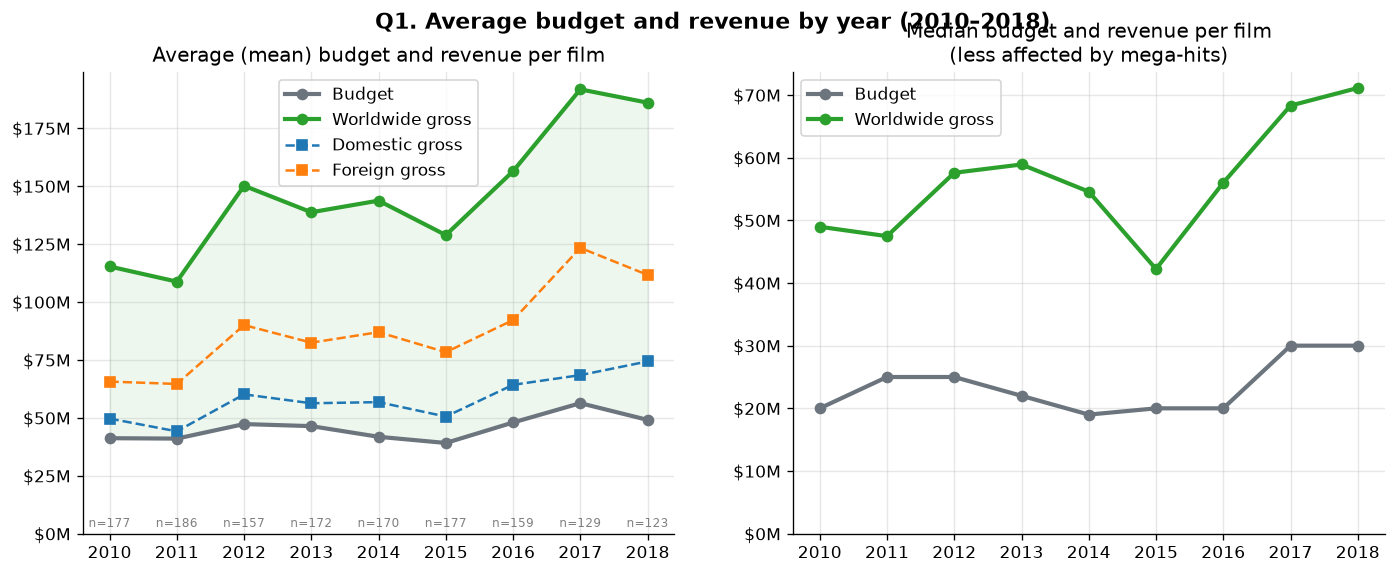

In [3]:
# ============================================================ Q1: budget/revenue by year
by_year = df.groupby("year").agg(
    films=("movie", "count"),
    budget_mean=("production_budget", "mean"),
    ww_mean=("worldwide_gross", "mean"),
    dom_mean=("domestic_gross", "mean"),
    for_mean=("foreign_gross", "mean"),
    budget_median=("production_budget", "median"),
    ww_median=("worldwide_gross", "median"),
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(by_year.index, by_year["budget_mean"], "o-", c=C_BUDGET, lw=2.5, label="Budget")
ax1.plot(by_year.index, by_year["ww_mean"], "o-", c=C_WW, lw=2.5, label="Worldwide gross")
ax1.plot(by_year.index, by_year["dom_mean"], "s--", c=C_DOM, label="Domestic gross")
ax1.plot(by_year.index, by_year["for_mean"], "s--", c=C_FOR, label="Foreign gross")
ax1.fill_between(by_year.index, by_year["budget_mean"], by_year["ww_mean"],
                 color=C_WW, alpha=0.08)
ax1.yaxis.set_major_formatter(millions)
ax1.set_title("Average (mean) budget and revenue per film")
ax1.legend()
for yr, n in by_year["films"].items():
    ax1.annotate(f"n={n}", (yr, 0), xytext=(0, 4), textcoords="offset points",
                 ha="center", fontsize=7, color="grey")
ax1.set_ylim(bottom=0)

ax2.plot(by_year.index, by_year["budget_median"], "o-", c=C_BUDGET, lw=2.5, label="Budget")
ax2.plot(by_year.index, by_year["ww_median"], "o-", c=C_WW, lw=2.5, label="Worldwide gross")
ax2.yaxis.set_major_formatter(millions)
ax2.set_title("Median budget and revenue per film\n(less affected by mega-hits)")
ax2.legend()
ax2.set_ylim(bottom=0)

fig.suptitle("Q1. Average budget and revenue by year (2010–2018)", fontweight="bold", fontsize=13)
#save(fig, "q1_budget_revenue_by_year.png")




Text(0.5, 1.0, 'Q2a. Domestic vs foreign gross by year')

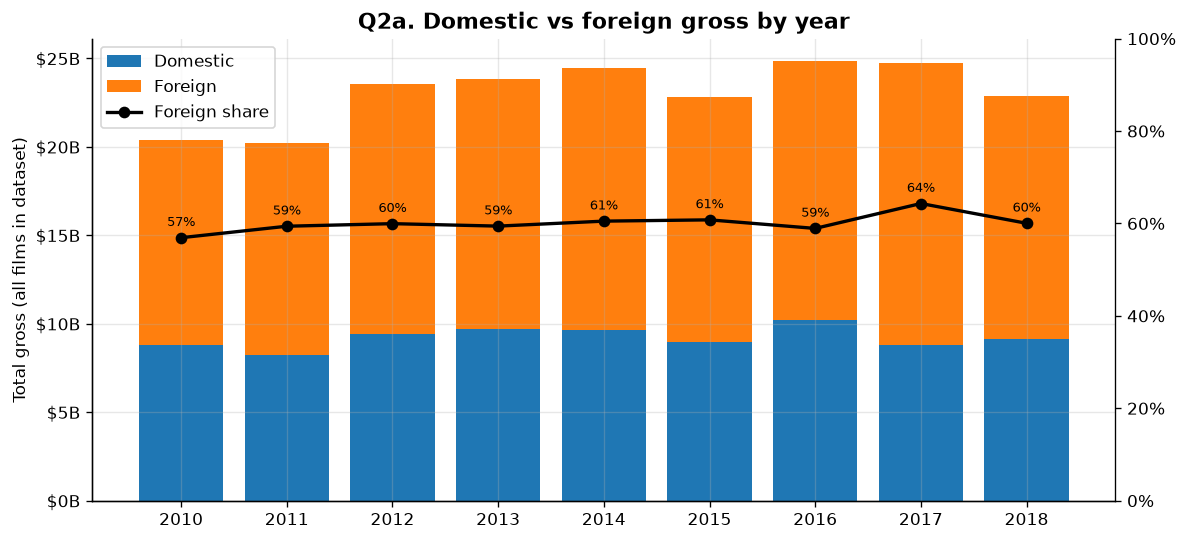

In [4]:
# ============================================================ Q2a: domestic vs foreign by year
totals = df.groupby("year")[["domestic_gross", "foreign_gross"]].sum()
share_foreign = totals["foreign_gross"] / totals.sum(axis=1)

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(totals.index, totals["domestic_gross"], color=C_DOM, label="Domestic")
ax.bar(totals.index, totals["foreign_gross"], bottom=totals["domestic_gross"],
       color=C_FOR, label="Foreign")
ax.yaxis.set_major_formatter(billions)
ax.set_ylabel("Total gross (all films in dataset)")
ax.set_xticks(totals.index)

ax_r = ax.twinx()
ax_r.plot(share_foreign.index, share_foreign, "ko-", lw=2, label="Foreign share")
ax_r.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax_r.set_ylim(0, 1)
ax_r.grid(False)
ax_r.spines["right"].set_visible(True)
for yr, s in share_foreign.items():
    ax_r.annotate(f"{s:.0%}", (yr, s), xytext=(0, 7), textcoords="offset points",
                  ha="center", fontsize=8)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax_r.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left")
ax.set_title("Q2a. Domestic vs foreign gross by year", fontweight="bold", fontsize=13)
#save(fig, "q2a_domestic_foreign_by_year.png")

Text(0.5, 1.0, 'Q2c. Foreign share of gross by genre and year')

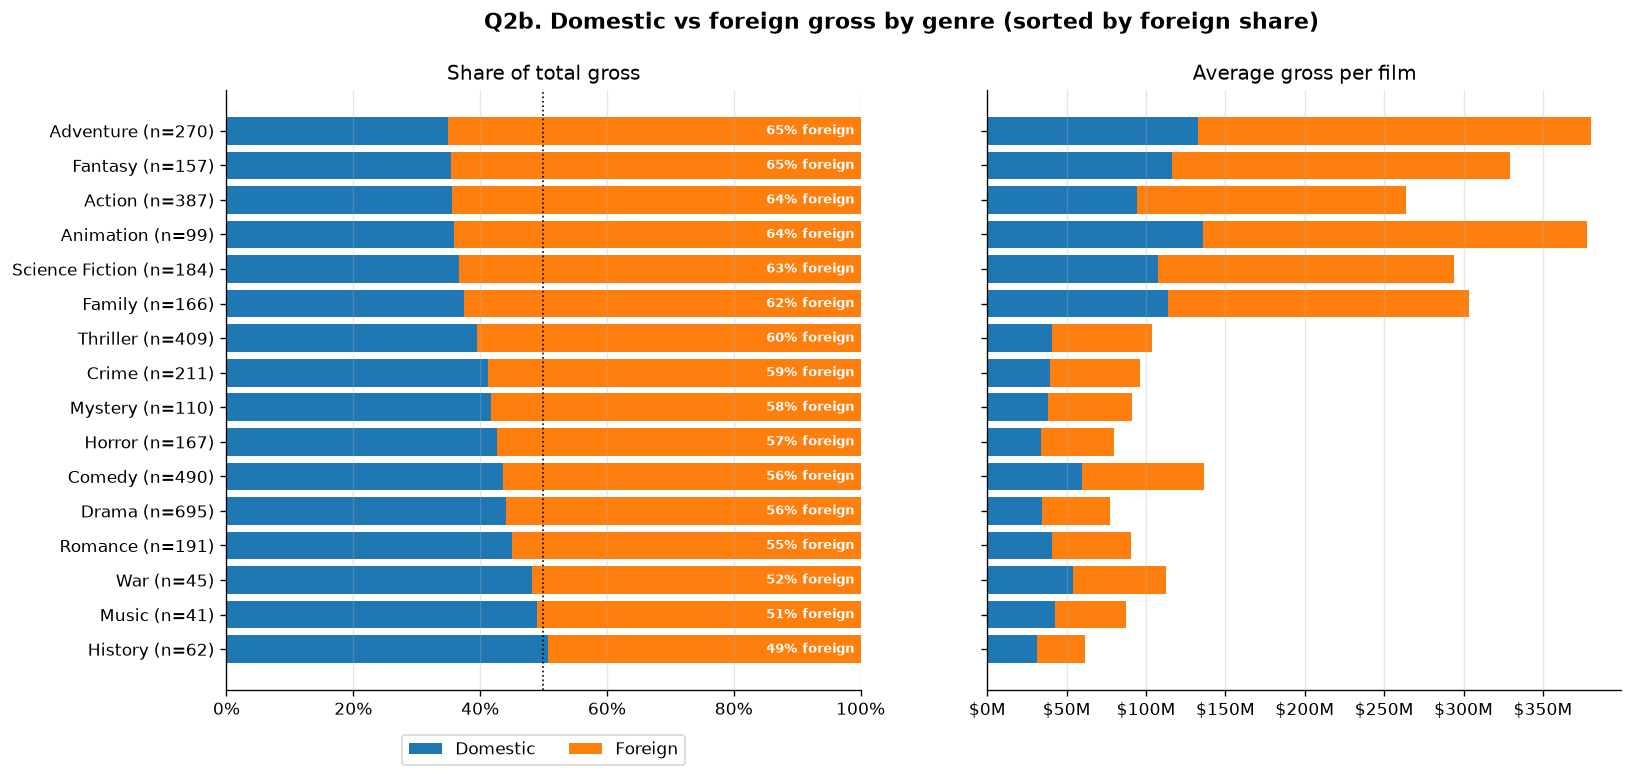

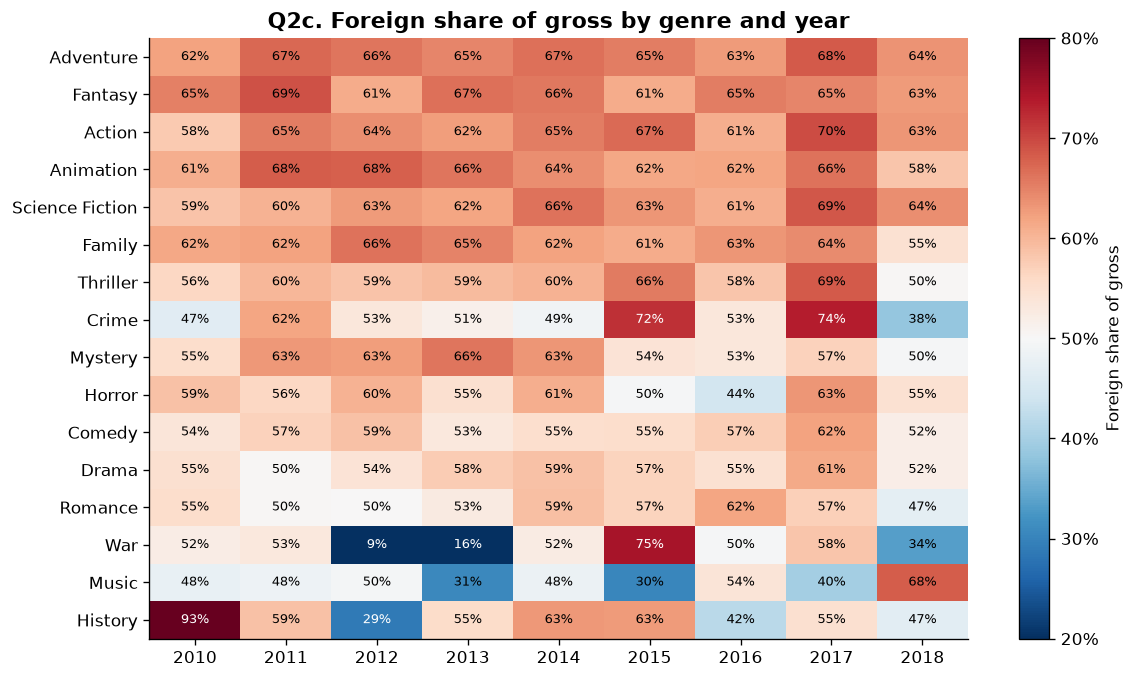

In [7]:
# ============================================================ Q2b: domestic vs foreign by genre
# Genres are multi-label: a film tagged Action+Adventure counts toward both.
rows = []
for g in genre_cols:
    sub = df[df[g] == 1]
    if len(sub) < MIN_GENRE_FILMS:
        continue
    dom, fgn = sub["domestic_gross"].sum(), sub["foreign_gross"].sum()
    rows.append({"genre": g, "films": len(sub),
                 "dom_share": dom / (dom + fgn), "for_share": fgn / (dom + fgn),
                 "avg_dom": sub["domestic_gross"].mean(),
                 "avg_for": sub["foreign_gross"].mean()})
genre = pd.DataFrame(rows).sort_values("for_share")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5), sharey=True)
y = np.arange(len(genre))
labels = [f"{g} (n={n})" for g, n in zip(genre["genre"], genre["films"])]

ax1.barh(y, genre["dom_share"], color=C_DOM, label="Domestic")
ax1.barh(y, genre["for_share"], left=genre["dom_share"], color=C_FOR, label="Foreign")
ax1.axvline(0.5, color="k", ls=":", lw=1)
for i, s in enumerate(genre["for_share"]):
    ax1.text(0.99, i, f"{s:.0%} foreign", va="center", ha="right", fontsize=8, color="white",
             fontweight="bold")
ax1.set_yticks(y, labels)
ax1.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1.set_xlim(0, 1)
ax1.set_title("Share of total gross")
ax1.legend(loc="upper center", bbox_to_anchor=(0.5, -0.06), ncol=2)
ax1.grid(axis="y", visible=False)

ax2.barh(y, genre["avg_dom"], color=C_DOM, label="Domestic")
ax2.barh(y, genre["avg_for"], left=genre["avg_dom"], color=C_FOR, label="Foreign")
ax2.xaxis.set_major_formatter(millions)
ax2.set_title("Average gross per film")
ax2.grid(axis="y", visible=False)

fig.suptitle("Q2b. Domestic vs foreign gross by genre (sorted by foreign share)",
             fontweight="bold", fontsize=13)
#save(fig, "q2b_domestic_foreign_by_genre.png")

# Bonus heatmap: foreign share by genre x year
heat = pd.DataFrame({
    g: df[df[g] == 1].groupby("year").apply(
        lambda s: s["foreign_gross"].sum() / s["worldwide_gross"].sum(),
        include_groups=False)
    for g in genre["genre"]
}).T.loc[genre["genre"][::-1]]

fig, ax = plt.subplots(figsize=(11, 6.5))
im = ax.imshow(heat.values, cmap="RdBu_r", vmin=0.2, vmax=0.8, aspect="auto")
ax.set_xticks(range(len(heat.columns)), heat.columns)
ax.set_yticks(range(len(heat.index)), heat.index)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=7.5,
                    color="white" if abs(v - 0.5) > 0.2 else "black")
ax.grid(False)
fig.colorbar(im, ax=ax, format=mtick.PercentFormatter(1.0), label="Foreign share of gross")
ax.set_title("Q2c. Foreign share of gross by genre and year", fontweight="bold", fontsize=13)

In [ ]:
# ============================================================ Q3: blockbusters vs others
# grp_year = df.groupby(["year", "group"]).agg(
#     films=("movie", "count"),
#     median_roi=("roi", "median"),
#     foreign_share=("pct_foreign", "median"),
#     loss_rate=("profit", lambda p: (p < 0).mean()),
# ).reset_index()
# colors = {"Blockbuster ($100M+)": C_BB, "Other films": C_OTHER}

# fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# # (a) budget vs worldwide gross scatter
# ax = axes[0, 0]
# for name, sub in df.groupby("group"):
#     ax.scatter(sub["production_budget"], sub["worldwide_gross"].clip(lower=1e4),
#                s=12, alpha=0.5, c=colors[name], label=name)
# lims = [1e4, 3e9]
# ax.plot(lims, lims, "k--", lw=1, label="Break-even (gross = budget)")
# ax.set_xscale("log"); ax.set_yscale("log")
# ax.axvline(BLOCKBUSTER_BUDGET, color=C_BB, ls=":", lw=1)
# ax.set_xlabel("Production budget (log)"); ax.set_ylabel("Worldwide gross (log)")
# ax.set_title("Budget vs worldwide gross")
# ax.legend(fontsize=8)

# # (b) ROI distribution
# ax = axes[0, 1]
# data = [df.loc[df["group"] == g, "roi"].clip(upper=15) for g in colors]
# bp = ax.boxplot(data, tick_labels=list(colors), patch_artist=True, showfliers=False, widths=0.5)
# for patch, c in zip(bp["boxes"], colors.values()):
#     patch.set_facecolor(c); patch.set_alpha(0.6)
# ax.axhline(0, color="k", lw=1)
# ax.set_ylim(top=ax.get_ylim()[1] * 1.2)
# ax.set_ylabel("ROI  (profit / budget)")
# ax.set_title("ROI distribution (outliers hidden)")
# for i, g in enumerate(colors, start=1):
#     sub = df[df["group"] == g]
#     ax.text(i, ax.get_ylim()[1] * 0.93,
#             f"median {sub['roi'].median():.2f}x\nloss rate {(sub['profit'] < 0).mean():.0%}",
#             ha="center", fontsize=8.5, va="top")

# # (c) number of blockbusters per year
# ax = axes[0, 2]
# pivot = grp_year.pivot(index="year", columns="group", values="films")
# share_bb = pivot["Blockbuster ($100M+)"] / pivot.sum(axis=1)
# ax.bar(pivot.index, pivot["Blockbuster ($100M+)"], color=C_BB, alpha=0.8)
# ax.set_ylabel("Blockbusters released")
# ax.set_xticks(pivot.index)
# ax_r = ax.twinx()
# ax_r.plot(share_bb.index, share_bb, "ko-")
# ax_r.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
# ax_r.set_ylim(0, share_bb.max() * 1.4)
# ax_r.set_ylabel("Share of all films"); ax_r.grid(False)
# ax_r.spines["right"].set_visible(True)
# ax.set_title("Blockbuster count and share of releases")

# # (d,e,f) trends over time
# for ax, col, title, fmt in [
#     (axes[1, 0], "median_roi", "Median ROI by year", mtick.FuncFormatter(lambda x, _: f"{x:.1f}x")),
#     (axes[1, 1], "foreign_share", "Median foreign share of gross", mtick.PercentFormatter(1.0)),
#     (axes[1, 2], "loss_rate", "Share of films losing money\n(worldwide gross < budget)", mtick.PercentFormatter(1.0)),
# ]:
#     for name, sub in grp_year.groupby("group"):
#         ax.plot(sub["year"], sub[col], "o-", c=colors[name], lw=2, label=name)
#     ax.yaxis.set_major_formatter(fmt)
#     ax.set_title(title)
#     ax.set_ylim(bottom=0)
#     ax.set_xticks(range(2010, 2019))
#     ax.legend(fontsize=8)

# fig.suptitle("Q3. Do blockbusters ($100M+ budget) behave differently?",
#              fontweight="bold", fontsize=14)
# save(fig, "q3_blockbusters_vs_others.png")

# # Bonus: genre mix of blockbusters vs others
# mix = pd.DataFrame({g: df.groupby("group")[g].mean() for g in genre["genre"]}).T
# mix = mix.sort_values("Blockbuster ($100M+)")
# fig, ax = plt.subplots(figsize=(10, 6.5))
# y = np.arange(len(mix))
# ax.barh(y + 0.2, mix["Blockbuster ($100M+)"], height=0.4, color=C_BB, label="Blockbuster ($100M+)")
# ax.barh(y - 0.2, mix["Other films"], height=0.4, color=C_OTHER, label="Other films")
# ax.set_yticks(y, mix.index)
# ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
# ax.set_xlabel("% of films tagged with genre (films can have several genres)")
# ax.legend(loc="lower right")
# ax.grid(axis="y", visible=False)
# ax.set_title("Q3b. Genre mix: blockbusters vs other films", fontweight="bold", fontsize=13)
# save(fig, "q3b_genre_mix_blockbusters.png")


# # ---------------------------------------------------------------- summary tables
# money = by_year.columns.drop("films")
# print("\nBy year ($M):\n", by_year.assign(**{c: (by_year[c] / 1e6).round(1) for c in money}).to_string())
# print("\nForeign share by year:\n", share_foreign.round(3).to_string())
# print("\nBy genre:\n", genre.round(3).to_string(index=False))
# print("\nBlockbusters vs others:\n",
#       df.groupby("group").agg(films=("movie", "count"),
#                               median_budget=("production_budget", "median"),
#                               median_ww=("worldwide_gross", "median"),
#                               median_roi=("roi", "median"),
#                               mean_roi=("roi", "mean"),
#                               median_foreign=("pct_foreign", "median"),
#                               loss_rate=("profit", lambda p: (p < 0).mean()),
#                               avg_rating=("vote_average", "mean")).round(3).to_string())